In [14]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from dotenv import load_dotenv
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.store.base import BaseStore
from langgraph.graph import START,END,StateGraph,MessagesState
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import uuid
from typing import List
import os

load_dotenv()

True

In [2]:
store = InMemoryStore()

In [3]:
extractor_llm = ChatOpenAI(model='gpt-4o-mini')

In [5]:
class MemoryItem(BaseModel):
    text : str = Field(description='Atomic user memory as a short sentence')
    is_new : bool = Field(description='True if the memory is new and should be stored. False if Duplicate/already known.')

In [6]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="whether to store any memories.")
    memories : List[MemoryItem] = Field(default_factory=list, description="atomic user memories to store")

In [7]:
ext_llm_with_structure = extractor_llm.with_structured_output(MemoryDecision)

In [8]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    Greetings and transitions
    Help or guidance tailored to tools and frameworks the user uses
    Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assume

In the end suggest 3 relevant further questions based on the current response and use

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [9]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [10]:
def remember_node(state:MessagesState, config:RunnableConfig, store:BaseStore):
    user_id = config.get('configurable',{})['user_id']
    namespace = ('user',user_id,'details')
    last_mssg = state['messages'][-1].content
    user_details_content = "\n".join(f'-- {it.value.get('data','')}' for it in store.search(namespace))
    memory_mssg = MEMORY_PROMPT.format(user_details_content=user_details_content)
    decision = ext_llm_with_structure.invoke([SystemMessage(content=memory_mssg),
                                                            {'role':'user','content':last_mssg}
                                                    ]
                                                )

    if decision.should_write:               #type:ignore
        for mem in decision.memories:       #type:ignore
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{'data':mem.text})

    return {'messages': [{'role':'assistant', 'content':'Noted.'}]}

In [15]:
chat_llm = ChatGroq(
    model="openai/gpt-oss-20b", 
    api_key=os.getenv("GROQ_API_KEY"), #type:ignore
    temperature=0.4
)

In [16]:
def chat_node(state:MessagesState, config:RunnableConfig, store:BaseStore):
    user_id = config.get('configurable',{})['user_id']
    namespace = ('user',user_id,'details')

    items = store.search(namespace)
    user_detail = "\n".join(it.value['data'] for it in items) if items else ""

    system_mssg = SystemMessage(content = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_detail) or "(empty)")
    rez = chat_llm.invoke([system_mssg]+state['messages'])
    return {'messages':[rez]}

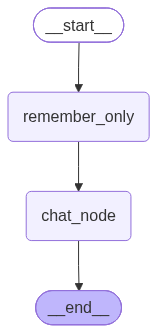

In [17]:
builder = StateGraph(MessagesState)
builder.add_node("remember_only", remember_node)
builder.add_node("chat_node", chat_node)

builder.add_edge(START, "remember_only")
builder.add_edge("remember_only",'chat_node')
builder.add_edge("chat_node", END)

graph = builder.compile(store=store)

graph

In [18]:
config = {'configurable':{'user_id':'u1'}}

rez = graph.invoke({'messages':[HumanMessage(content='Hello my name is Edward.') ]},config=config) # type:ignore

print(rez['messages'][-1].content)

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_wri...Edward.", is_new=True)]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


Hi Edward! 👋 How can I help you today?  

**Some quick ways we could get started:**

1. Are you working on a specific project or learning a new technology?  
2. Do you need help debugging code or setting up an environment?  
3. Would you like suggestions for resources or tutorials on a particular topic?


In [19]:
items = store.search(('user','u1','details'))

for it in items:
    print(it.value['data'])

User's name is Edward.


In [20]:
rez = graph.invoke({'messages':[HumanMessage(content='I study AI from MIT.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_wri...om MIT.', is_new=True)]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


Hey Edward! That’s awesome—MIT’s AI program is top‑tier. How’s your coursework going? Are you focusing on any particular subfield (e.g., RL, NLP, computer vision) or working on a project right now?  

**Quick follow‑up questions that might help me tailor my support:**

1. Are you looking for resources or tools to boost your current AI projects?  
2. Do you need help with a specific research paper or algorithm?  
3. Would you like suggestions for open‑source datasets or competitions to try out?


In [21]:
items = store.search(('user','u1','details'))

for it in items:
    print(it.value['data'])

User's name is Edward.
Edward studies AI from MIT.


In [22]:
rez = graph.invoke({'messages':[HumanMessage(content='Explain GenAI simply and in easy words.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_write=False, memories=[]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


Hey Edward!  
**GenAI** (short for *Generative Artificial Intelligence*) is a type of AI that can *create* things—text, images, music, code, and more—rather than just *recognize* or *classify* them. Think of it like a super‑creative robot that learns from tons of examples and then produces new content that looks or sounds like something a human might make.

### How it works in plain English

| Step | What happens | Why it matters |
|------|--------------|----------------|
| 1. **Learn** | The model reads (or sees, hears, etc.) a huge dataset—books, articles, photos, code, etc. | It picks up patterns, styles, and relationships in the data. |
| 2. **Encode** | It turns that information into a mathematical “fingerprint” (weights in a neural network). | This fingerprint lets the model remember what it’s seen. |
| 3. **Generate** | When you give it a prompt (e.g., “Write a short poem about rain”), it uses its fingerprint to craft something new that fits the prompt. | The output is original,

In [23]:
items = store.search(('user','u1','details'))

for it in items:
    print(it.value['data'])

User's name is Edward.
Edward studies AI from MIT.
